# ElasticNet Regression

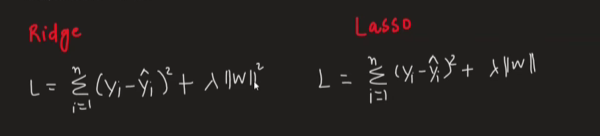

### Summarizing the use of Ridge and Lasso regression:

1. Ridge hum ese data set pe use karenge, jisme saare features important hai, aur hum chahte hai ki unka contribution model mei ho, but we want to reduce the overfitting by adding a penalty term to the loss function.

2. Lasso hum uss data set pe use karenge jaha hume pata ho ki saare features ka ek subset important hai, so we increase the value of $\lambda$ to make the coefficients of the less important features exactly zero, which helps in feature selection and creating a sparse model.

- **But suppose if you have a dataset with large number of features (say 100 columns), and you are not sure which features are important and which are not, then in that case we can use ElasticNet regression.**

- ElasticNet regression is a linear regression model that combines the properties of both Ridge and Lasso regression. It uses a linear combination of the L1 and L2 penalties to regularize the model. The formula for ElasticNet regression is:

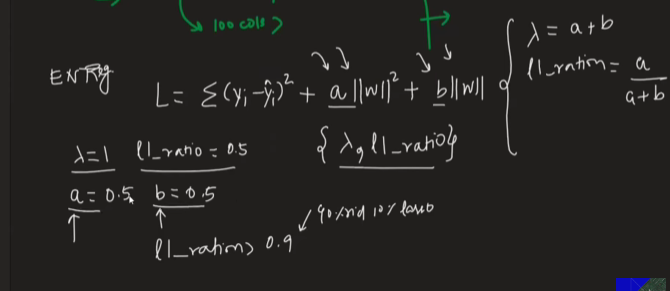

### $\text{ElasticNet} = \text{MSE} + a \sum_{i=1}^{n} |W_i| + b \sum_{i=1}^{n} W_i^2$

In sklearn implementation of ElasticNet regression, we have a parameter called `l1_ratio` and $\alpha$ which is used to control the balance between L1 and L2 penalties.

- ### $\alpha = a + b$

- ### `l1_ratio` = $\frac{a}{a + b}$ = $\frac{a}{\alpha}$

- By default, $\alpha = 1.0$ and $l1\_ratio = 0.5$ ( $a = 0.5$ and $b = 0.5$ ), which means that the model will have equal contribution from both L1 and L2 penalties.

- If we increase the value of `l1_ratio` to say 0.8, it means 80% contribution from L1 penalty and 20% contribution from L2 penalty, which will make the model more sparse and will perform feature selection.

-  ### Also if our input column have multicollinearity (i.e. high correlation between the features), then we can use ElasticNet regression 

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
X,y = load_diabetes(return_X_y=True)

In [3]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [4]:
# Linear Regression
reg = LinearRegression()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.439933866156897

In [5]:
# Ridge 
reg = Ridge(alpha=0.1)
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.45199494197195456

In [6]:
# Lasso
reg = Lasso(alpha=0.01)
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.44111855963110613

In [10]:
# ElasticNet default
elastic_reg = ElasticNet()
elastic_reg.fit(X_train,y_train)
y_pred = elastic_reg.predict(X_test)
r2_score(y_test,y_pred)

-0.0033640473527960513

In [11]:
elastic_reg.l1_ratio , elastic_reg.alpha

(0.5, 1.0)

In [8]:
# ElasticNet
ela_reg = ElasticNet(alpha=0.005,l1_ratio=0.9)
ela_reg.fit(X_train,y_train)
y_pred = ela_reg.predict(X_test)
r2_score(y_test,y_pred)

0.4531474541554823

In [9]:
ela_reg.l1_ratio , ela_reg.alpha

(0.9, 0.005)

- You can implement ElasticNet regression using SGDRegressor in sklearn by setting the `penalty` parameter to 'elasticnet' and adjusting the `alpha` and `l1_ratio` parameters according to your needs.